In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [3]:
from saidownscale.config import setup_cluster

client = setup_cluster()
client

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_src │ Source wheel built from                                 │
│                    │ ~/dev/carbonplan/srm-downscaling/src                    │
│   saidownscale     │ Wheel built from ~/dev/carbonplan/srm-downscaling       │
│   srm              │ Wheel built from ~/dev/carbonplan/srm-downscaling       │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

2026-09-18 15:41:56,678 - distributed.deploy.adaptive - INFO - Adaptive scaling started: minimum=1 maximum=50


<Client: 'tls://10.1.6.240:8786' processes=0 threads=0, memory=0 B>

In [4]:
SOURCE_COOP_BUCKET = "us-west-2.opendata.source.coop"
SOURCE_COOP_ROOT = "carbonplan/srm-downscaling"
INPUT_STORE = "input/processed/CESM2-WACCM6.icechunk"


def open_source_coop(store, group, branch="main", chunks=None):
    storage = icechunk.s3_storage(
        bucket=SOURCE_COOP_BUCKET,
        prefix=f"{SOURCE_COOP_ROOT}/{store}",
        anonymous=True,
        region="us-west-2",
    )
    session = icechunk.Repository.open(storage).readonly_session(branch=branch)
    return xr.open_zarr(
        session.store, group=group, consolidated=False, zarr_format=3, chunks=chunks or {}
    )

In [5]:
ds_dict = {
    "historical": open_source_coop(INPUT_STORE, "historical").sel(
        ensemble_member=["001"], time=slice("1978", "2014")
    ),
    "ssp2-4.5": open_source_coop(INPUT_STORE, "ssp245").sel(time=slice("2015", "2100")),
    "g6-1.5k": open_source_coop(INPUT_STORE, "g6_1p5k").sel(time=slice("2035", "2085")),
}

In [6]:
def complete_annual_mean(series, min_days=360):
    """Annual mean over the years each ensemble member individually covers.

    Masks any (member, year) with fewer than ``min_days`` valid days, so partial
    years (staggered ensemble end dates, mid-year run ends) drop out instead of
    collapsing into a spurious single-day mean. Each member is kept to its own
    last complete year, so a ragged ensemble (SSP245 members 006-010 end ~2070
    while 001-005 run to 2100) thins out rather than being cut to the shortest.
    """
    valid_days = series.notnull().groupby("time.year").sum()
    return series.groupby("time.year").mean().where(valid_days >= min_days)

In [7]:
dfs = []
for scenario, ds in ds_dict.items():
    series = ds.tas.weighted(np.cos(np.deg2rad(ds.lat))).mean(dim=["lat", "lon"])
    _df = (
        complete_annual_mean(series)
        .rename("value")
        .to_dataframe()
        .reset_index()
        .dropna(subset=["value"])
    )
    _df["scenario"] = scenario
    _df["gcm"] = str(ds.model)
    _df["variable"] = "tas_global"
    dfs.append(_df)

df = pd.concat(dfs, ignore_index=True)[
    ["year", "scenario", "ensemble_member", "gcm", "variable", "value"]
]

## Termination (SAI shutoff, 2085-2100)

Injection stops after 2084 in `G6-1p5K-termination_002` (branched from member 002), published as the `g6_1p5k_end` group of the input store.

In [8]:
ds_term = open_source_coop(INPUT_STORE, "g6_1p5k_end")

series = ds_term.tas.weighted(np.cos(np.deg2rad(ds_term.lat))).mean(dim=["lat", "lon"])
annual = complete_annual_mean(series).compute()

df_term = annual.rename("value").to_dataframe().reset_index().dropna(subset=["value"])
df_term["scenario"] = "g6-1.5k-term"
df_term["gcm"] = str(ds_term.model)
df_term["variable"] = "tas_global"
df_term = df_term[df.columns]
df_term

,year,scenario,ensemble_member,gcm,variable,value
0,2085,g6-1.5k-term,002,CESM2-WACCM,tas_global,288.904856
1,2086,g6-1.5k-term,002,CESM2-WACCM,tas_global,289.266537
2,2087,g6-1.5k-term,002,CESM2-WACCM,tas_global,289.344776
3,2088,g6-1.5k-term,002,CESM2-WACCM,tas_global,289.292823
4,2089,g6-1.5k-term,002,CESM2-WACCM,tas_global,289.602344
5,2090,g6-1.5k-term,002,CESM2-WACCM,tas_global,289.659164
6,2091,g6-1.5k-term,002,CESM2-WACCM,tas_global,289.670943
7,2092,g6-1.5k-term,002,CESM2-WACCM,tas_global,289.795971
8,2093,g6-1.5k-term,002,CESM2-WACCM,tas_global,289.906348
9,2094,g6-1.5k-term,002,CESM2-WACCM,tas_global,289.793067


In [9]:
df_all = pd.concat([df, df_term], ignore_index=True)

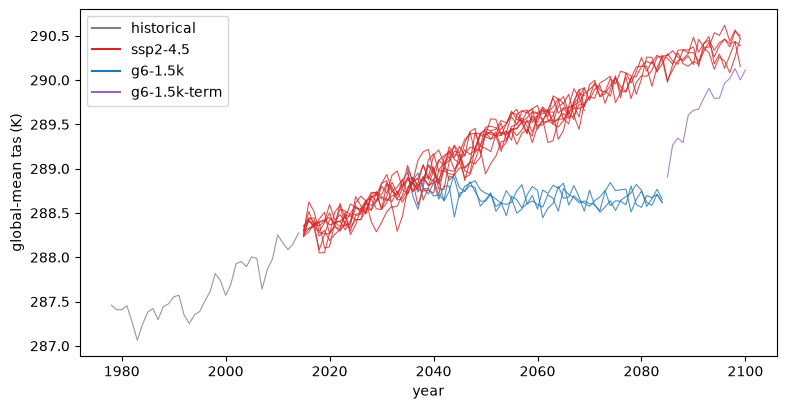

In [10]:
colors = {
    "historical": "0.5",
    "ssp2-4.5": "tab:red",
    "g6-1.5k": "tab:blue",
    "g6-1.5k-term": "tab:purple",
}

fig, ax = plt.subplots(figsize=(9, 4.5))
for (scenario, member), group in df_all.groupby(["scenario", "ensemble_member"]):
    ax.plot(group.year, group.value, color=colors[scenario], lw=0.8, alpha=0.8)
for scenario, color in colors.items():
    ax.plot([], [], color=color, label=scenario)  # legend proxies (one entry per scenario)
ax.set(xlabel="year", ylabel="global-mean tas (K)")
ax.legend()

In [11]:
df_all

,year,scenario,ensemble_member,gcm,variable,value
0,1978,historical,001,CESM2-WACCM,tas_global,287.459650
1,1979,historical,001,CESM2-WACCM,tas_global,287.408042
2,1980,historical,001,CESM2-WACCM,tas_global,287.407511
3,1981,historical,001,CESM2-WACCM,tas_global,287.452167
4,1982,historical,001,CESM2-WACCM,tas_global,287.268021
...,...,...,...,...,...,...
898,2096,g6-1.5k-term,002,CESM2-WACCM,tas_global,289.964605
899,2097,g6-1.5k-term,002,CESM2-WACCM,tas_global,290.018398
900,2098,g6-1.5k-term,002,CESM2-WACCM,tas_global,290.129978
901,2099,g6-1.5k-term,002,CESM2-WACCM,tas_global,290.001058


In [12]:
df_all.to_csv("s3://carbonplan-srm/output/explainer/figures/figure2.csv")

## Prescribed GHG concentrations

`co2vmr`, `ch4vmr`, and `n2ovmr` are read from member 001's raw NetCDFs on Source Cooperative because they are excluded from the icechunk stores and identical across members.

In [13]:
import obstore as obs
from obspec_utils.readers import BlockStoreReader
from obstore.store import S3Store

RAW_NETCDF_PREFIX = "input/raw/CESM2-WACCM6/netcdf"

GHG_VARS = {
    "co2vmr": ("co2_ppm", 1e6),
    "ch4vmr": ("ch4_ppb", 1e9),
    "n2ovmr": ("n2o_ppb", 1e9),
}

GHG_SCENARIOS = {
    "historical": ("historical", 1978, 2014),
    "ssp245": ("ssp2-4.5", 2015, 2100),
    "g6-1p5k": ("g6-1.5k", 2035, 2084),
}

store = S3Store(
    SOURCE_COOP_BUCKET, prefix=SOURCE_COOP_ROOT, region="us-west-2", skip_signature=True
)


def raw_netcdf_paths(drop, cesm_var, member):
    listing = obs.list_with_delimiter(
        store, prefix=f"{RAW_NETCDF_PREFIX}/{drop}", return_arrow=True
    )
    return sorted(
        p
        for p in listing["objects"]["path"].to_numpy()
        if p.endswith(".nc") and f".{member}.cam." in p and f".{cesm_var}." in p
    )


def open_ghg_scalars(store, path):
    """Load only the scalar GHG series from a CAM history file (block-cached reads, no dask)."""
    reader = BlockStoreReader(store, path, block_size=4_194_304)
    return xr.open_dataset(reader, engine="h5netcdf")[list(GHG_VARS)].load()

In [14]:
ghg_dfs = []
for drop, (name, y0, y1) in GHG_SCENARIOS.items():
    paths = raw_netcdf_paths(drop, "TREFHT", "001")
    daily = xr.concat([open_ghg_scalars(store, p) for p in paths], dim="time")
    for cesm_var, (variable, scale) in GHG_VARS.items():
        annual = complete_annual_mean(daily[cesm_var]).dropna("year")
        _df = (annual * scale).rename("value").to_dataframe().reset_index()
        _df = _df[(_df.year >= y0) & (_df.year <= y1)]
        _df["scenario"] = name
        _df["gcm"] = "CESM2-WACCM"
        _df["variable"] = variable
        ghg_dfs.append(_df)

df_ghg = pd.concat(ghg_dfs, ignore_index=True)[["year", "scenario", "gcm", "variable", "value"]]
df_ghg

,year,scenario,gcm,variable,value
0,1978,historical,CESM2-WACCM,co2_ppm,335.003204
1,1979,historical,CESM2-WACCM,co2_ppm,336.599424
2,1980,historical,CESM2-WACCM,co2_ppm,338.698288
3,1981,historical,CESM2-WACCM,co2_ppm,340.050020
4,1982,historical,CESM2-WACCM,co2_ppm,340.637263
...,...,...,...,...,...
514,2080,g6-1.5k,CESM2-WACCM,n2o_ppb,373.367006
515,2081,g6-1.5k,CESM2-WACCM,n2o_ppb,373.688986
516,2082,g6-1.5k,CESM2-WACCM,n2o_ppb,373.994965
517,2083,g6-1.5k,CESM2-WACCM,n2o_ppb,374.285947


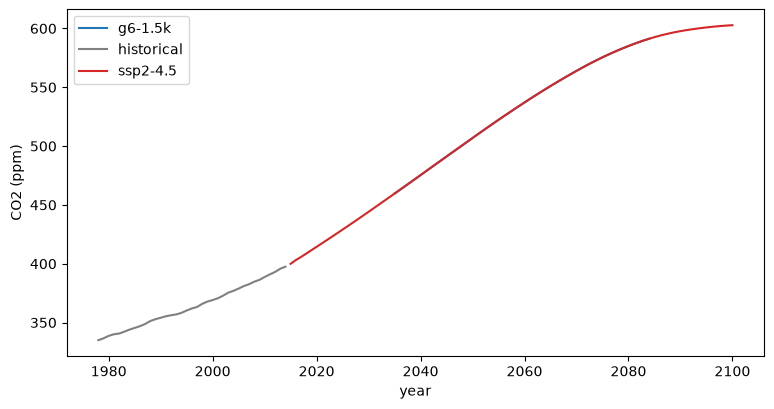

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for scenario, group in df_ghg[df_ghg.variable == "co2_ppm"].groupby("scenario"):
    ax.plot(group.year, group.value, color=colors[scenario], label=scenario)
ax.set(xlabel="year", ylabel="CO2 (ppm)")
ax.legend()

In [16]:
df_ghg.to_csv("s3://carbonplan-srm/output/explainer/figures/figure2-ghg.csv")

## SSP2-4.5 CO₂ emissions

Total CO₂ emissions (fossil + land use) come from RCMIP's harmonized SSP2-4.5 pathway and are linearly interpolated to annual. G6-1.5K-SAI uses the same pathway.

In [17]:
RCMIP_URL = "https://rcmip-protocols-au.s3-ap-southeast-2.amazonaws.com/v5.1.0/rcmip-emissions-annual-means-v5-1-0.csv"

rcmip = pd.read_csv(RCMIP_URL)
row = rcmip[
    (rcmip.Scenario == "ssp245") & (rcmip.Region == "World") & (rcmip.Variable == "Emissions|CO2")
].iloc[0]

year_cols = [c for c in row.index if c.isdigit()]
raw = pd.Series({int(y): float(row[y]) for y in year_cols if pd.notnull(row[y])}).sort_index()
annual_co2 = raw.reindex(range(1978, 2101)).interpolate(method="index") / 1000  # Mt -> Gt CO2/yr

EMIS_SPANS = {"historical": (1978, 2014), "ssp2-4.5": (2015, 2100), "g6-1.5k": (2035, 2084)}
emis_dfs = []
for scenario, (y0, y1) in EMIS_SPANS.items():
    _df = annual_co2.loc[y0:y1].rename("value").rename_axis("year").reset_index()
    _df["scenario"] = scenario
    _df["source"] = "SSP2-4.5 (RCMIP harmonized)"
    _df["variable"] = "co2_emissions_GtCO2"
    emis_dfs.append(_df)

df_emis = pd.concat(emis_dfs, ignore_index=True)[
    ["year", "scenario", "source", "variable", "value"]
]
df_emis

,year,scenario,source,variable,value
0,1978,historical,SSP2-4.5 (RCMIP harmonized),co2_emissions_GtCO2,25.215439
1,1979,historical,SSP2-4.5 (RCMIP harmonized),co2_emissions_GtCO2,25.589011
2,1980,historical,SSP2-4.5 (RCMIP harmonized),co2_emissions_GtCO2,25.266664
3,1981,historical,SSP2-4.5 (RCMIP harmonized),co2_emissions_GtCO2,24.889467
4,1982,historical,SSP2-4.5 (RCMIP harmonized),co2_emissions_GtCO2,24.681493
...,...,...,...,...,...
168,2080,g6-1.5k,SSP2-4.5 (RCMIP harmonized),co2_emissions_GtCO2,26.838373
169,2081,g6-1.5k,SSP2-4.5 (RCMIP harmonized),co2_emissions_GtCO2,25.786975
170,2082,g6-1.5k,SSP2-4.5 (RCMIP harmonized),co2_emissions_GtCO2,24.735577
171,2083,g6-1.5k,SSP2-4.5 (RCMIP harmonized),co2_emissions_GtCO2,23.684179


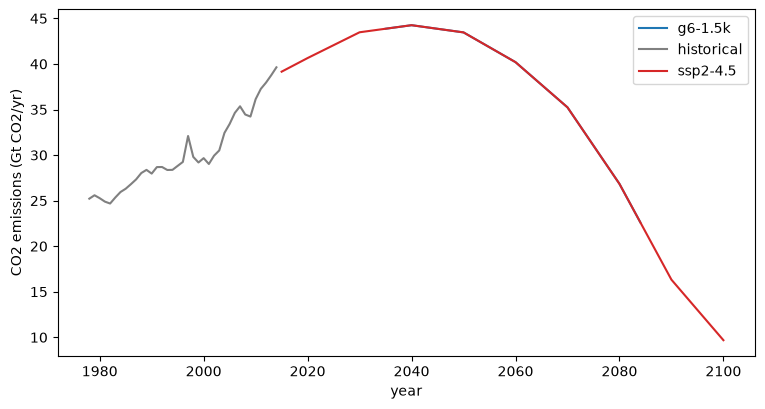

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for scenario, group in df_emis.groupby("scenario"):
    ax.plot(group.year, group.value, color=colors[scenario], label=scenario)
ax.set(xlabel="year", ylabel="CO2 emissions (Gt CO2/yr)")
ax.legend()

In [19]:
df_emis.to_csv("s3://carbonplan-srm/output/explainer/figures/figure2-co2-emissions.csv")

## SO₂ injection rates

Annual injection is the sum of the 30°N and 30°S `ControlLog` values ([Zenodo record 17613419](https://zenodo.org/records/17613419), Lee et al.). Rates vary by member and are clipped to 2035–2084.

In [20]:
import io
import zipfile

import requests

ZENODO_SO2_URL = "https://zenodo.org/records/17613419/files/SO2%20injection%20rates.zip?download=1"

resp = requests.get(ZENODO_SO2_URL)
resp.raise_for_status()
zf = zipfile.ZipFile(io.BytesIO(resp.content))

so2_dfs = []
for member in ["001", "002", "003"]:
    name = f"SO2 injection rates/CESM_ControlLog_b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.{member}.txt"
    log = pd.read_csv(zf.open(name), sep=r"\s+")
    _df = pd.DataFrame(
        {"year": log["Timestamp"].astype(int), "value": log["30N(Tg)"] + log["30S(Tg)"]}
    )
    _df = _df[(_df.year >= 2035) & (_df.year <= 2084)]
    _df["scenario"] = "g6-1.5k"
    _df["ensemble_member"] = member
    _df["gcm"] = "CESM2-WACCM"
    _df["variable"] = "so2_injection_Tg"
    so2_dfs.append(_df)

df_so2 = pd.concat(so2_dfs, ignore_index=True)[
    ["year", "scenario", "ensemble_member", "gcm", "variable", "value"]
]
df_so2

,year,scenario,ensemble_member,gcm,variable,value
0,2035,g6-1.5k,001,CESM2-WACCM,so2_injection_Tg,1.041000
1,2036,g6-1.5k,001,CESM2-WACCM,so2_injection_Tg,1.418956
2,2037,g6-1.5k,001,CESM2-WACCM,so2_injection_Tg,1.830599
3,2038,g6-1.5k,001,CESM2-WACCM,so2_injection_Tg,2.437157
4,2039,g6-1.5k,001,CESM2-WACCM,so2_injection_Tg,2.886361
...,...,...,...,...,...,...
145,2080,g6-1.5k,003,CESM2-WACCM,so2_injection_Tg,13.266024
146,2081,g6-1.5k,003,CESM2-WACCM,so2_injection_Tg,13.384535
147,2082,g6-1.5k,003,CESM2-WACCM,so2_injection_Tg,13.758312
148,2083,g6-1.5k,003,CESM2-WACCM,so2_injection_Tg,13.974305


[Text(0.5, 0, 'year'), Text(0, 0.5, 'SO2 injection (Tg/yr)')]

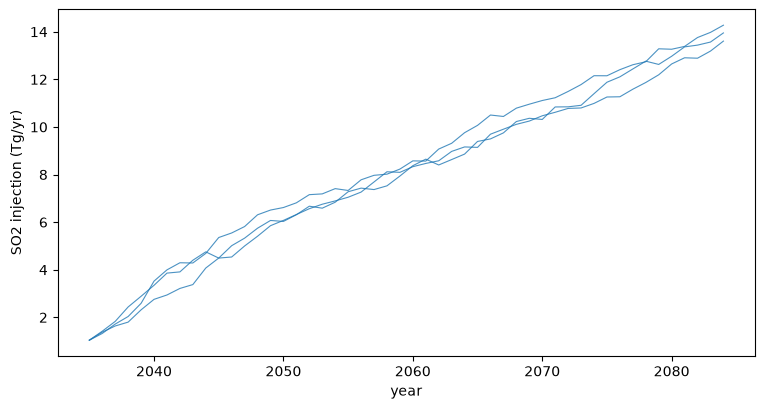

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for member, group in df_so2.groupby("ensemble_member"):
    ax.plot(group.year, group.value, color=colors["g6-1.5k"], lw=0.8, alpha=0.8)
ax.set(xlabel="year", ylabel="SO2 injection (Tg/yr)")

In [22]:
df_so2.to_csv("s3://carbonplan-srm/output/explainer/figures/figure2-so2.csv")

## Stratospheric aerosol optical depth (550 nm)

Global-mean stratospheric 550 nm AOD (`AODVISstdn`) from the same dataset. Monthly timestamps are shifted to bounds midpoints before cos(lat)-weighted annual aggregation.

In [23]:
import io  # noqa: E402

from remotezip import RemoteZip  # noqa: E402

ZENODO_AOD_URL = (
    "https://zenodo.org/records/17613419/files/Stratospheric%20550nm%20AOD.zip?download=1"
)


def annual_global_mean_aod(ds):
    # Monthly h0 means are timestamped at period-end; use the bounds midpoint
    # so each mean lands in its true calendar year.
    aod = ds.AODVISstdn.assign_coords(time=ds.time_bnds.mean("nbnd"))
    gmean = aod.weighted(np.cos(np.deg2rad(ds.lat))).mean(dim=["lat", "lon"])
    valid = gmean.notnull().groupby("time.year").count()
    annual = gmean.groupby("time.year").mean().where(valid >= 12).dropna("year")
    return annual.sel(year=slice(2035, 2084))


aod_dfs = []
with RemoteZip(ZENODO_AOD_URL) as z:
    cesm_files = [n for n in z.namelist() if "/CESM_" in n and n.endswith(".nc")]
    for name in sorted(cesm_files):
        member = name.split("SSP245-G6-1p5K-SAI.")[1][:3]
        ds = xr.open_dataset(io.BytesIO(z.read(name)), engine="h5netcdf")
        annual = annual_global_mean_aod(ds)
        _df = annual.rename("value").to_dataframe().reset_index()
        _df["scenario"] = "g6-1.5k"
        _df["ensemble_member"] = member
        _df["gcm"] = "CESM2-WACCM"
        _df["variable"] = "stratospheric_aod_550nm"
        aod_dfs.append(_df)

df_aod = pd.concat(aod_dfs, ignore_index=True)[
    ["year", "scenario", "ensemble_member", "gcm", "variable", "value"]
]
df_aod

,year,scenario,ensemble_member,gcm,variable,value
0,2035,g6-1.5k,001,CESM2-WACCM,stratospheric_aod_550nm,0.014607
1,2036,g6-1.5k,001,CESM2-WACCM,stratospheric_aod_550nm,0.025730
2,2037,g6-1.5k,001,CESM2-WACCM,stratospheric_aod_550nm,0.033700
3,2038,g6-1.5k,001,CESM2-WACCM,stratospheric_aod_550nm,0.042231
4,2039,g6-1.5k,001,CESM2-WACCM,stratospheric_aod_550nm,0.051405
...,...,...,...,...,...,...
145,2080,g6-1.5k,003,CESM2-WACCM,stratospheric_aod_550nm,0.182076
146,2081,g6-1.5k,003,CESM2-WACCM,stratospheric_aod_550nm,0.175718
147,2082,g6-1.5k,003,CESM2-WACCM,stratospheric_aod_550nm,0.180980
148,2083,g6-1.5k,003,CESM2-WACCM,stratospheric_aod_550nm,0.185073


[Text(0.5, 0, 'year'), Text(0, 0.5, 'stratospheric AOD (550 nm)')]

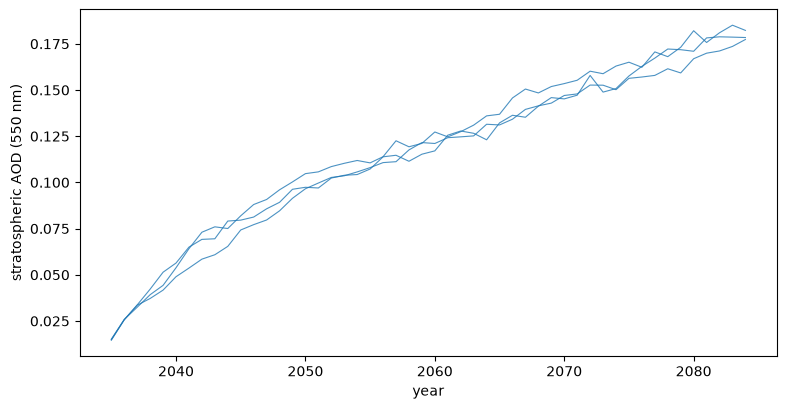

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for member, group in df_aod.groupby("ensemble_member"):
    ax.plot(group.year, group.value, color=colors["g6-1.5k"], lw=0.8, alpha=0.8)
ax.set(xlabel="year", ylabel="stratospheric AOD (550 nm)")

In [25]:
df_aod.to_csv("s3://carbonplan-srm/output/explainer/figures/figure2-aod.csv")

In [26]:
client.shutdown()

2026-09-18 15:49:28,186 - distributed.deploy.adaptive - INFO - Adaptive scaling stopped: minimum=1 maximum=50. Reason: unknown
